In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('cleaned_statements.csv')
df.head(10)

,statement,status
0,oh gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,wrong back dear forward doubt stay restless re...,Anxiety
3,shifted focus something else still worried,Anxiety
4,restless restless month boy mean,Anxiety
5,every break must nervous like something wrong ...,Anxiety
6,feel scared anxious may family protected,Anxiety
7,ever felt nervous know,Anxiety
8,slept well day like restless huh,Anxiety
9,really worried want cry,Anxiety


In [3]:
# Label encoding
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['status'])
# Split data into features and labels
X = df['statement'] 
y = df['label']


In [4]:
df

,statement,status,label
0,oh gosh,Anxiety,0
1,trouble sleeping confused mind restless heart ...,Anxiety,0
2,wrong back dear forward doubt stay restless re...,Anxiety,0
3,shifted focus something else still worried,Anxiety,0
4,restless restless month boy mean,Anxiety,0
...,...,...,...
52676,nobody take seriously dealt depression anxiety...,Anxiety,0
52677,selfishness feel good like belong world think ...,Anxiety,0
52678,way sleep better sleep night med help,Anxiety,0
52679,public speaking tip hi give presentation work ...,Anxiety,0


In [5]:
df.isnull().sum()

statement    186
status         0
label          0
dtype: int64

In [6]:
df = df.dropna(subset=['statement', 'status', 'label'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52495 entries, 0 to 52680
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52495 non-null  object
 1   status     52495 non-null  object
 2   label      52495 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ MB


In [8]:
df.isnull().sum()

statement    0
status       0
label        0
dtype: int64

In [9]:
df.nunique()

statement    50350
status           7
label            7
dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_2796\779470379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_df.index, y=count_df.values, palette='viridis')


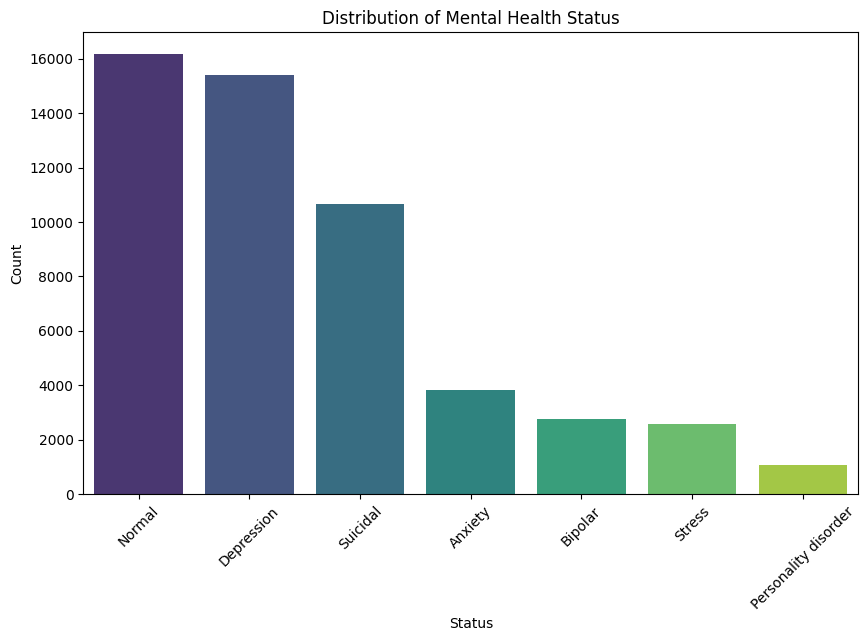

In [10]:
count_df = df['status'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=count_df.index, y=count_df.values, palette='viridis')
plt.title('Distribution of Mental Health Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2796\27609464.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count.index, y=count.values, palette='viridis')


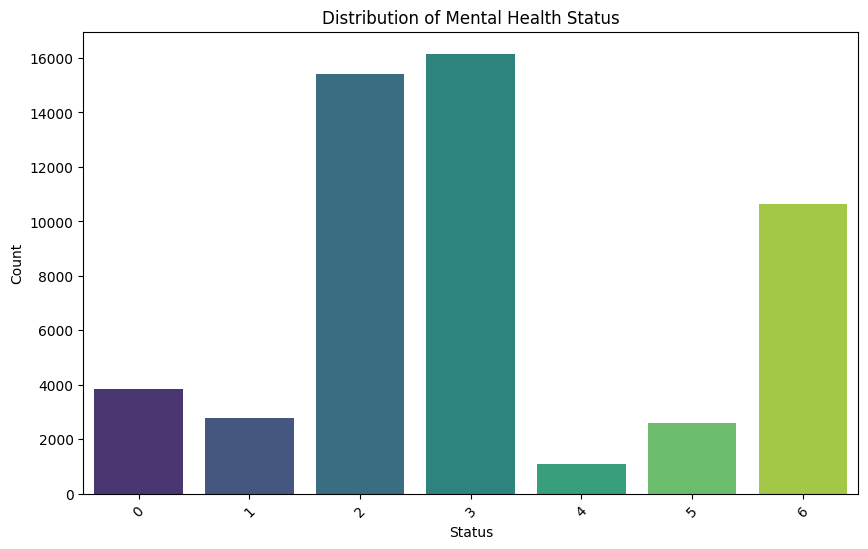

In [11]:
count = df['label'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=count.index, y=count.values, palette='viridis')
plt.title('Distribution of Mental Health Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [12]:
print("status",count_df)
print(": label",count)

status status
Normal                  16161
Depression              15403
Suicidal                10649
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64
: label label
3    16161
2    15403
6    10649
0     3841
1     2777
5     2587
4     1077
Name: count, dtype: int64


In [13]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['statement'])
print(f"Shape of TF-IDF matrix: {X.shape}")

Shape of TF-IDF matrix: (52495, 5000)


In [14]:
y = df['label'] 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
model = LogisticRegression(max_iter=100)


In [16]:
model

LogisticRegression()

In [17]:
model.fit(X_train, y_train)

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [19]:
y_pred = model.predict(X_test)


In [21]:
print(y_test)
print(y_pred)


11330    2
26515    6
9751     2
17574    6
2067     3
        ..
21364    6
23766    6
39271    2
5230     3
6840     3
Name: label, Length: 10499, dtype: int64
[6 2 6 ... 0 3 3]


In [22]:
print("classification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


classification report:
                      precision    recall  f1-score   support

             Anxiety       0.82      0.71      0.76       768
             Bipolar       0.88      0.64      0.75       556
          Depression       0.67      0.73      0.70      3081
              Normal       0.83      0.95      0.89      3232
Personality disorder       0.88      0.40      0.54       215
              Stress       0.68      0.38      0.49       517
            Suicidal       0.67      0.63      0.65      2130

            accuracy                           0.75     10499
           macro avg       0.78      0.63      0.68     10499
        weighted avg       0.75      0.75      0.74     10499



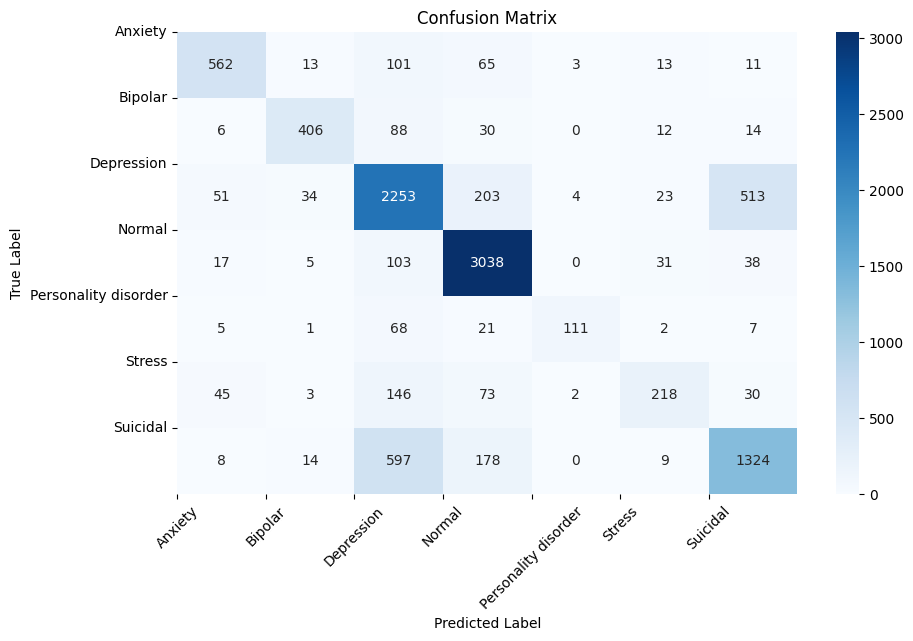

In [32]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xticks(ticks=range(len(label_encoder.classes_)), labels=label_encoder.classes_, rotation=45)
plt.yticks(ticks=range(len(label_encoder.classes_)), labels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [25]:
import xgboost as xgb
from xgboost import XGBClassifier

In [26]:
XgBoostClassifier = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')


In [27]:
XgBoostClassifier.fit(X_train, y_train)

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [10:35:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
y_pred = XgBoostClassifier.predict(X_test)


In [29]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


                      precision    recall  f1-score   support

             Anxiety       0.81      0.73      0.77       768
             Bipolar       0.85      0.73      0.79       556
          Depression       0.67      0.73      0.70      3081
              Normal       0.84      0.94      0.89      3232
Personality disorder       0.93      0.52      0.66       215
              Stress       0.71      0.42      0.53       517
            Suicidal       0.68      0.62      0.65      2130

            accuracy                           0.75     10499
           macro avg       0.78      0.67      0.71     10499
        weighted avg       0.75      0.75      0.75     10499



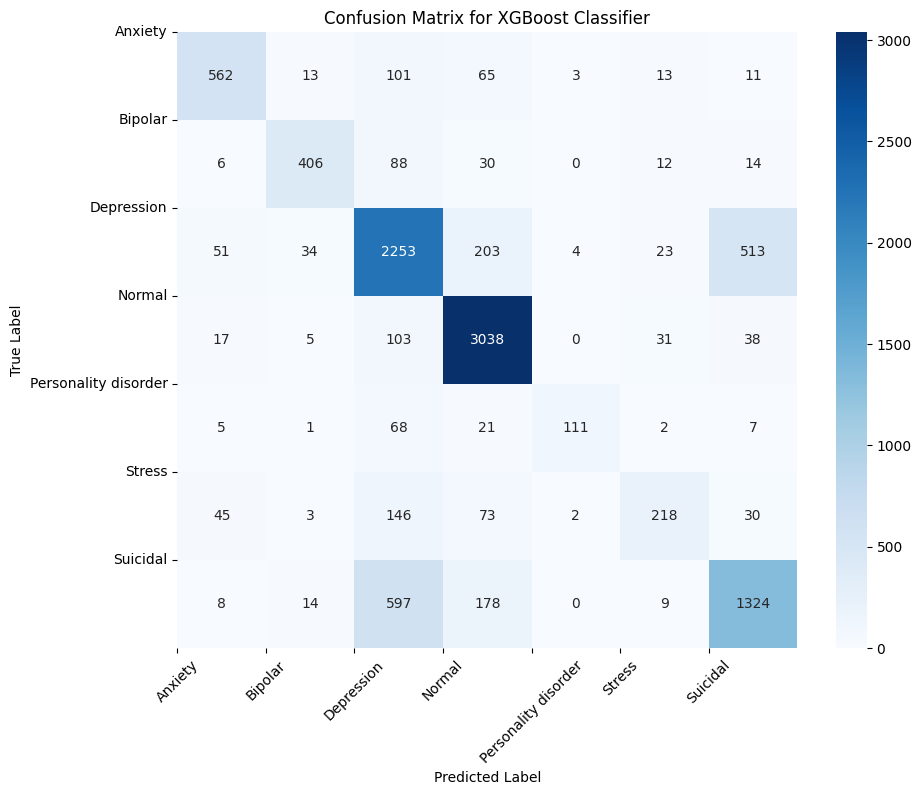

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xticks(ticks=range(len(label_encoder.classes_)), labels=label_encoder.classes_, rotation=45)
plt.yticks(ticks=range(len(label_encoder.classes_)), labels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [33]:
#save model 
import joblib
joblib.dump(model, 'model_logistic.pkl')
joblib.dump(XgBoostClassifier, 'xgboost_model.pkl')

['xgboost_model.pkl']

In [34]:
df.to_csv('cleaned_statements2.csv', index=False)
